In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

2026-05-01 07:43:00.074116: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 07:43:00.076193: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-01 07:43:00.118128: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-01 07:43:00.119087: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-01 07:43:01.117497: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Rutas del proyecto

In [2]:
ruta_entrenamiento = "/workspaces/imagenesclas.Rhonalmendoza/data/train"
ruta_prueba = "/workspaces/imagenesclas.Rhonalmendoza/data/test"


Visualización de imágenes

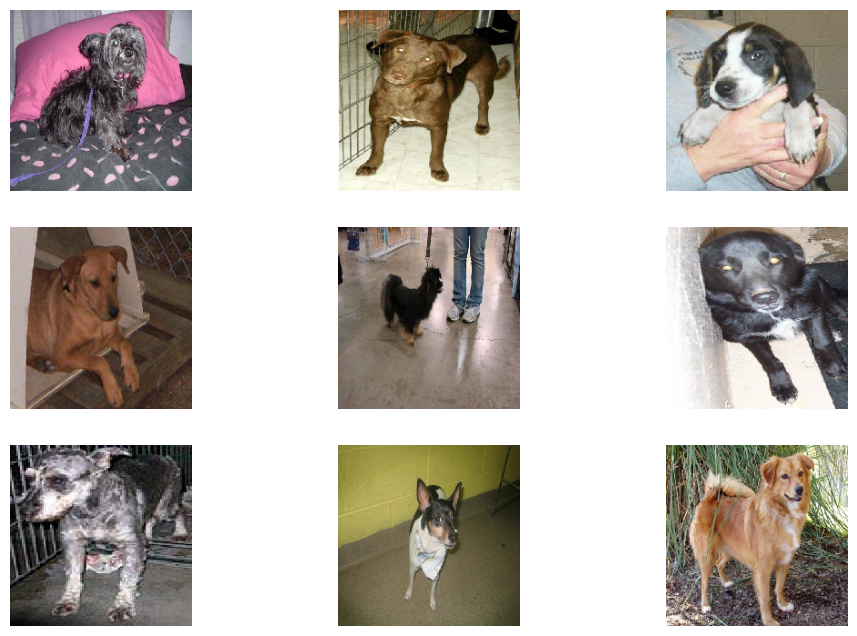

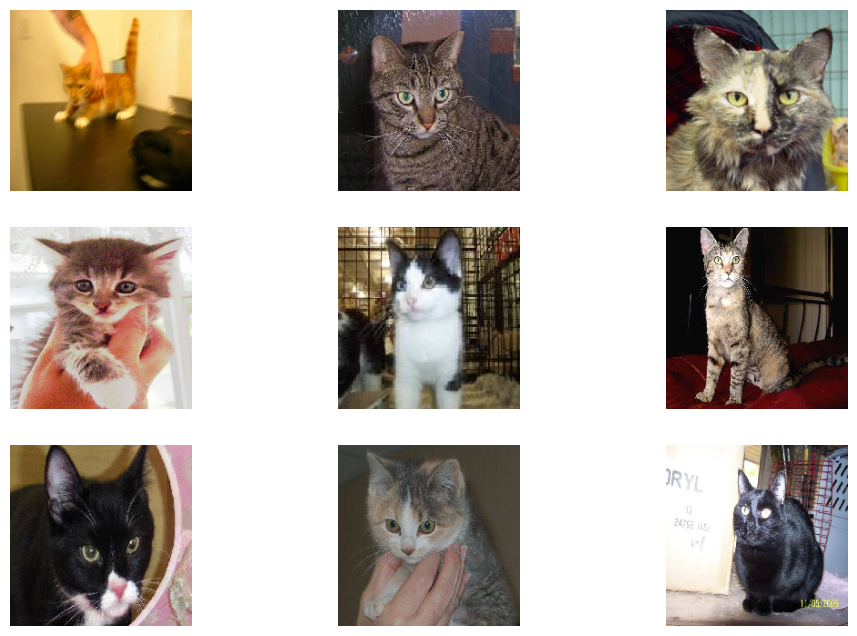

In [3]:
# Visualizar 9 perros
carpeta_perros = os.path.join(ruta_entrenamiento, "dog")
imagenes_perros = sorted(os.listdir(carpeta_perros))[:9]

plt.figure(figsize=(12,8))
for i, archivo in enumerate(imagenes_perros):
    img = image.load_img(os.path.join(carpeta_perros, archivo), target_size=(200,200))
    plt.subplot(3,3,i+1)
    plt.imshow(image.img_to_array(img)/255)
    plt.axis("off")
plt.show()

# Visualizar 9 gatos
carpeta_gatos = os.path.join(ruta_entrenamiento, "cat")
imagenes_gatos = sorted(os.listdir(carpeta_gatos))[:9]

plt.figure(figsize=(12,8))
for i, archivo in enumerate(imagenes_gatos):
    img = image.load_img(os.path.join(carpeta_gatos, archivo), target_size=(200,200))
    plt.subplot(3,3,i+1)
    plt.imshow(image.img_to_array(img)/255)
    plt.axis("off")
plt.show()


Generadores de datos

In [4]:
tamano_imagen = (128, 128)

generador_entrenamiento = ImageDataGenerator(rescale=1./255)
generador_prueba = ImageDataGenerator(rescale=1./255)

datos_entrenamiento = generador_entrenamiento.flow_from_directory(
    ruta_entrenamiento,
    target_size=tamano_imagen,
    batch_size=32,
    class_mode='sparse'
)

datos_prueba = generador_prueba.flow_from_directory(
    ruta_prueba,
    target_size=tamano_imagen,
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)


Found 22500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


Modelo CNN tipo VGG16

In [5]:
modelo = Sequential()

modelo.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
modelo.add(Conv2D(32, (3,3), padding="same", activation="relu"))
modelo.add(MaxPool2D((2,2)))

modelo.add(Conv2D(64, (3,3), padding="same", activation="relu"))
modelo.add(Conv2D(64, (3,3), padding="same", activation="relu"))
modelo.add(MaxPool2D((2,2)))

modelo.add(Conv2D(128, (3,3), padding="same", activation="relu"))
modelo.add(Conv2D(128, (3,3), padding="same", activation="relu"))
modelo.add(MaxPool2D((2,2)))

modelo.add(Flatten())
modelo.add(Dense(512, activation="relu"))
modelo.add(Dense(2, activation="softmax"))

modelo.compile(optimizer=Adam(1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

modelo.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                    

In [6]:
ruta_guardado = "/workspaces/imagenesclas.Rhonalmendoza/models"
os.makedirs(ruta_guardado, exist_ok=True)

ruta_mejor_modelo = os.path.join(ruta_guardado, "mejor_modelo.keras")

callback_guardado = ModelCheckpoint(
    ruta_mejor_modelo,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callback_temprano = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


Entrenamiento

In [ ]:
historial = modelo.fit(
    datos_entrenamiento,
    validation_data=datos_prueba,
    epochs=10,
    callbacks=[callback_guardado, callback_temprano]
)

Epoch 1/10


2026-05-01 07:47:04.335658: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


450/704 [==================>...........] - ETA: 8:10 - loss: 0.6020 - accuracy: 0.6632

Evaluación del modelo

In [ ]:
modelo_optimo = load_model(ruta_mejor_modelo)
perdida, precision = modelo_optimo.evaluate(datos_prueba)

print("Precisión en el conjunto de prueba:", precision)


Guardado

In [ ]:
ruta_modelo_final = os.path.join(ruta_guardado, "modelo_final.keras")
modelo.save(ruta_modelo_final)

print("Modelo final guardado en:", ruta_modelo_final)
